# 🍽️ Zomato Global Restaurant Insights: Exploratory Data Analysis
---
## Introduction
Zomato is one of India's largest food delivery and restaurant discovery platforms, operating in 24 countries with over 1.5 million restaurants listed. This project performs an **Exploratory Data Analysis (EDA)** on Zomato's restaurant dataset to uncover meaningful patterns and business insights.

As a data analyst, the goal is not just to plot charts — but to **tell a story with data** that can help Zomato make better business decisions around restaurant partnerships, city expansion, pricing strategy, and customer experience.

---
## Objectives
- Understand the structure and quality of the dataset
- Clean and prepare data for analysis
- Answer 8 key business questions through visual analysis
- Extract actionable insights from each analysis

---
## Tools & Libraries Used
| Tool | Purpose |
|---|---|
| Python | Core programming language |
| Pandas | Data manipulation and cleaning |
| NumPy | Numerical operations |
| Matplotlib | Basic visualizations |
| Seaborn | Advanced statistical plots |

---
##  Dataset Overview
**Source:** Zomato Restaurants Global Dataset  
**Format:** CSV  

###  Column Description
| Column Name | Description |
|---|---|
| restaurant id | Unique ID for each restaurant |
| restaurant name | Name of the restaurant |
| country code | Numeric code representing the country |
| city | City where the restaurant is located |
| address | Full address of the restaurant |
| locality | Locality/area within the city |
| locality verbose | Detailed locality with city name |
| longitude | Geographic longitude coordinate |
| latitude | Geographic latitude coordinate |
| cuisines | Type(s) of cuisine served |
| average cost for two | Average dining cost for two people |
| currency | Currency used for pricing |
| has table booking | Whether table booking is available (Yes/No) |
| has online delivery | Whether online delivery is available (Yes/No) |
| is delivering now | Whether currently delivering (Yes/No) |
| switch to order menu | Whether order menu switch is available |
| price range | Price range category (1=Budget to 4=Premium) |
| aggregate rating | Overall customer rating (0 to 5) |
| rating color | Color code based on rating |
| rating text | Text label (Excellent, Good, Average, Poor etc.) |
| votes | Total number of customer votes/reviews |

---
#SECTION 1: Setup & Import Libraries

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

---
#SECTION 2: Load Dataset

In [21]:
df = pd.read_csv('/content/zomato_restaurants.csv')
print('Dataset loaded successfully!')
print('Rows    :' ,df.shape[0])
print('Columns :',df.shape[1])
df.head()

Dataset loaded successfully!
Rows    : 9552
Columns : 23


,Unnamed: 0,Restaurant ID,Restaurant Name,Country Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,0,6317637,Le Petit Souffle,Phillipines,162.0,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,...,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,1,6304287,Izakaya Kikufuji,Phillipines,162.0,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,...,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,2,6300002,Heat - Edsa Shangri-La,Phillipines,162.0,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,...,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,3,6318506,Ooma,Phillipines,162.0,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,...,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,4,6314302,Sambo Kojin,Phillipines,162.0,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,...,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


---
#SECTION 3: Data Understanding

In [22]:
# Data types and memory info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9552 entries, 0 to 9551
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            9552 non-null   object 
 1   Restaurant ID         9552 non-null   object 
 2   Restaurant Name       9552 non-null   object 
 3   Country Name          9552 non-null   object 
 4   Country Code          9552 non-null   float64
 5   City                  9552 non-null   object 
 6   Address               9552 non-null   object 
 7   Locality              9551 non-null   object 
 8   Locality Verbose      9551 non-null   object 
 9   Longitude             9551 non-null   object 
 10  Latitude              9551 non-null   object 
 11  Cuisines              9542 non-null   object 
 12  Average Cost for two  9551 non-null   float64
 13  Currency              9551 non-null   object 
 14  Has Table booking     9551 non-null   object 
 15  Has Online delivery  

In [23]:
# Statistical summary of numeric columns
df.describe()

,Country Code,Average Cost for two,Price range,Aggregate rating,Votes
count,9552.000000,9551.000000,9550.000000,9550.000000,9550.000000
mean,18.363829,1199.201235,1.804607,2.666314,156.923037
std,56.747844,16121.183753,0.905378,1.516447,430.189709
min,1.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,250.000000,1.000000,2.500000,5.000000
50%,1.000000,400.000000,2.000000,3.200000,31.000000
75%,1.000000,700.000000,2.000000,3.700000,131.000000
max,216.000000,800000.000000,4.000000,4.900000,10934.000000


In [24]:
# All column names
print('Total Columns:',len(df.columns))
print(df.columns.tolist())

Total Columns: 23
['Unnamed: 0', 'Restaurant ID', 'Restaurant Name', 'Country Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


---
#SECTION 4: Data Cleaning

In [25]:
# Step 1: Drop unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print('Dropped \'Unnamed: 0\'')

# Step 2: Set column names in lowercase + strip spaces
df.columns = df.columns.str.lower().str.strip()
print('Column names into lowercase')
print(df.columns.tolist())

Dropped 'Unnamed: 0'
Column names into lowercase
['restaurant id', 'restaurant name', 'country name', 'country code', 'city', 'address', 'locality', 'locality verbose', 'longitude', 'latitude', 'cuisines', 'average cost for two', 'currency', 'has table booking', 'has online delivery', 'is delivering now', 'switch to order menu', 'price range', 'aggregate rating', 'rating color', 'rating text', 'votes']


In [26]:
# Step 3: Check and remove duplicate rows
dup_count = df.duplicated().sum()
print('Duplicate rows found:',dup_count)
if dup_count > 0:
    df = df.drop_duplicates()
    print('Duplicates removed')
else:
    print('No duplicates found')

Duplicate rows found: 0
No duplicates found


In [27]:
# Step 4: Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Total missing values:',df.isnull().sum().sum())
print()
if len(missing_df) > 0:
    print(missing_df)
else:
    print('No missing values found')

Total missing values: 31

                      Missing Count  Missing %
cuisines                         10       0.10
rating color                      2       0.02
votes                             2       0.02
rating text                       2       0.02
aggregate rating                  2       0.02
price range                       2       0.02
switch to order menu              2       0.02
locality                          1       0.01
has table booking                 1       0.01
currency                          1       0.01
average cost for two              1       0.01
latitude                          1       0.01
locality verbose                  1       0.01
longitude                         1       0.01
has online delivery               1       0.01
is delivering now                 1       0.01


In [28]:
# Step 5: Fix dtypes — convert to numeric where needed
for col in ['aggregate rating', 'longitude', 'latitude']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 6: Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print('Numeric columns:',len(numeric_cols),"\n",numeric_cols.tolist())
print()
print('Categorical columns:',len(categorical_cols),"\n",categorical_cols.tolist())

Numeric columns: 7 
 ['country code', 'longitude', 'latitude', 'average cost for two', 'price range', 'aggregate rating', 'votes']

Categorical columns: 15 
 ['restaurant id', 'restaurant name', 'country name', 'city', 'address', 'locality', 'locality verbose', 'cuisines', 'currency', 'has table booking', 'has online delivery', 'is delivering now', 'switch to order menu', 'rating color', 'rating text']


In [29]:
# Step 7: Fill missing values
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values after cleaning:',df.isnull().sum().sum())
print('Data cleaning complete!')

Missing values after cleaning: 0
Data cleaning complete!


---
# SECTION 5: Market Insights & Performance Analysis

---
**Objective: To identify cities with the highest number of restaurants**

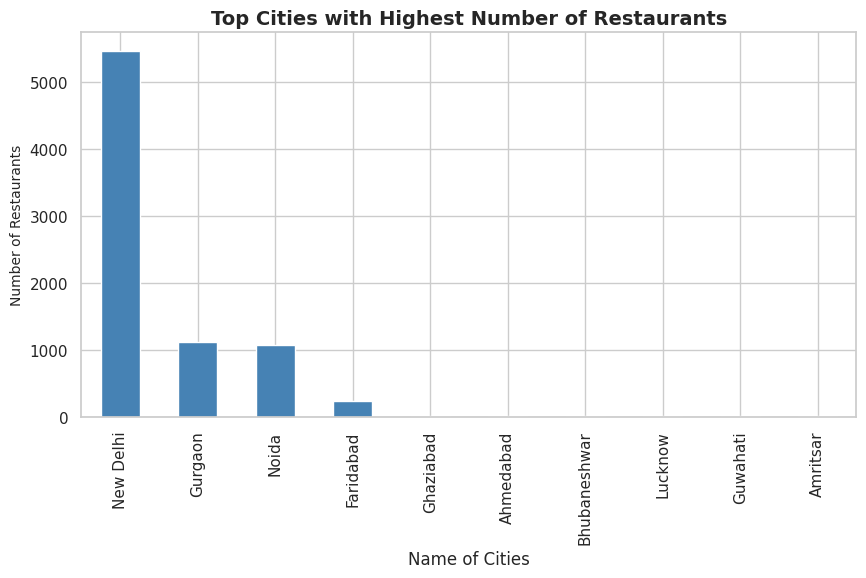

city
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Bhubaneshwar      21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64


In [30]:
# 1. Prepare the data
top_cities = df['city'].value_counts().head(10)

# 2. Create the visualization
top_cities.plot(kind='bar',color='steelblue')

# 3. Add labels and title
plt.title('Top Cities with Highest Number of Restaurants', fontsize=14, fontweight = 'bold')
plt.xlabel('Name of Cities', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=10)

# 4. Show plot and exact counts
plt.show()
print(top_cities)

**Insight:** New Delhi has the highest number of restaurants listed on Zomato, followed by other major metro cities. This reflects Zomato's stronger presence in large urban areas. Cities with fewer listings represent **potential expansion opportunities** for Zomato to onboard more restaurant partners.

---
**Objective: Rating Distribution Analysis & Segment Identification**





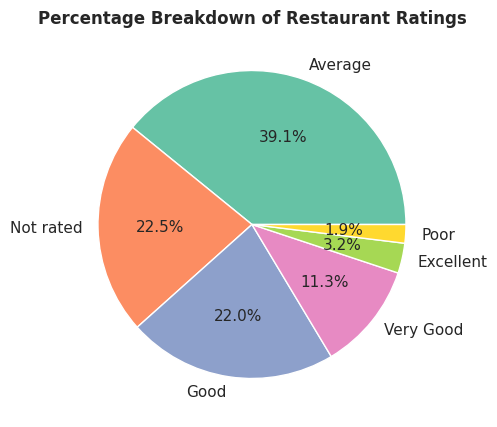

Total values  :  2100


,restaurant name,city,aggregate rating,rating text
15,Cafe Arabelle,Santa Rosa,3.6,Good
23,Cafí© Daniel Briand,Brasí_lia,3.8,Good
24,Casa do Biscoito Mineiro,Brasí_lia,3.7,Good
25,Maori,Brasí_lia,3.8,Good
28,Beirute,Brasí_lia,3.7,Good


In [31]:
# 1. Preparing Data
rating_counts = df['rating text'].value_counts()
rating_pct = (rating_counts / len(df) * 100).round(2)

# 2. Pie chart
rating_counts.plot(kind='pie',colors=sns.color_palette('Set2'),autopct='%1.1f%%')

# 3. Add Title and Label
plt.title("Percentage Breakdown of Restaurant Ratings", fontweight='bold')
plt.ylabel('')     #remove unwanted default label for cleaner plot
plt.show()

# 4. Filter Restaurants
condition = df['rating text'] == 'Good'
find_value = df[condition][['restaurant name', 'city', 'aggregate rating', 'rating text']]

# 5. Show Count &
print("Total values  : ",len(find_value))
find_value.head()


**Insight**: A large portion of restaurants are rated Average and Good, indicating balanced performance. Fewer restaurants fall into higher rating categories. This highlights opportunities for restaurants to **improve quality** and **attract better ratings**.

---
**Objective: To analyze the relationship between price range and restaurant ratings**

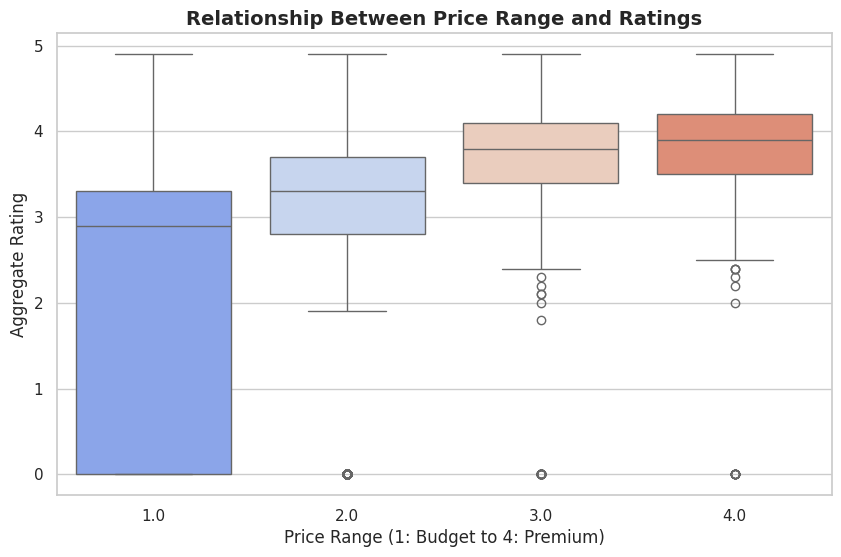

Average Rating by Price Range:


,aggregate rating
price range,
1.0,2.00
2.0,2.94
3.0,3.68
4.0,3.82


In [13]:
# 1. Set the visual style
plt.figure(figsize=(10, 6))

# 2. Create a boxplot to show distribution
sns.boxplot(x='price range', y='aggregate rating', data=df, palette='coolwarm')

# 3. Add professional labels
plt.title('Relationship Between Price Range and Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Price Range (1: Budget to 4: Premium)', fontsize=12)
plt.ylabel('Aggregate Rating', fontsize=12)
plt.show()

# 4. Display the exact mean rating for each range
print("Average Rating by Price Range:")
df.groupby('price range')['aggregate rating'].mean().round(2)

**Insight**: There is a clear upward trend—as the price range increases, the average rating also increases. Premium restaurants **(Price Range 4)** consistently maintain higher ratings.

---
**Objective: To analyze cuisine distribution and identify the most popular cuisines across restaurants**

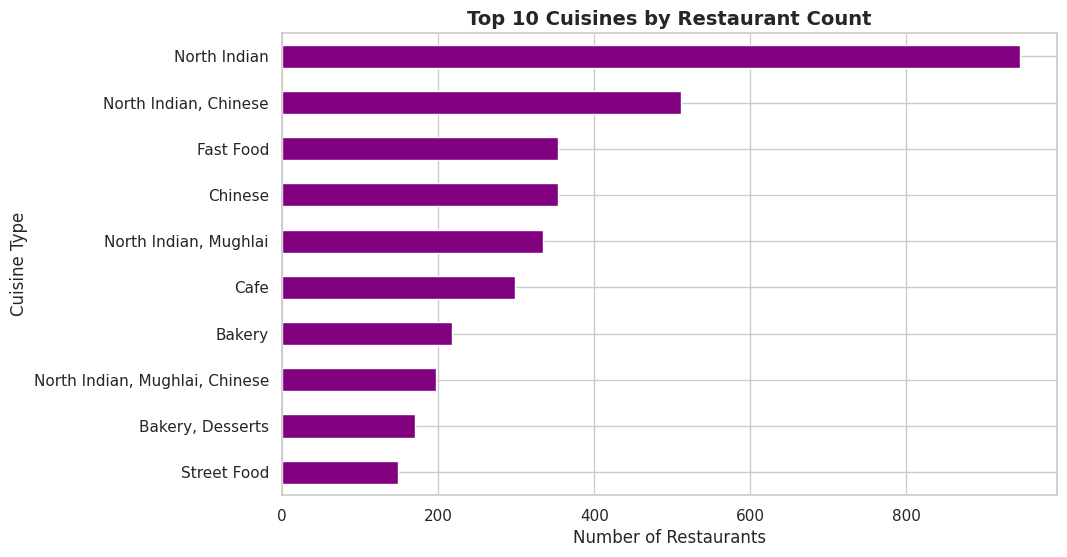

,count
cuisines,
North Indian,946
"North Indian, Chinese",511
Fast Food,354
Chinese,354
"North Indian, Mughlai",334
Cafe,299
Bakery,218
"North Indian, Mughlai, Chinese",197
"Bakery, Desserts",170


In [14]:
# 1. Extract the top 10 most frequent cuisines
top_cuisines = df['cuisines'].value_counts().head(10)

# 2. Plotting the horizontal bar chart for better readability
plt.figure(figsize=(10, 6))
top_cuisines.plot(kind='barh', color='purple').invert_yaxis()  # Invert to show highest at the top

# 3. Add professional styling and labels
plt.title("Top 10 Cuisines by Restaurant Count", fontsize=14, fontweight='bold')
plt.xlabel("Number of Restaurants", fontsize=12)
plt.ylabel("Cuisine Type", fontsize=12)

# 4. Display the chart and the raw data
plt.show()
top_cuisines

**Insight:** North Indian and Chinese cuisines dominate the platform, reflecting the **real-world food preferences** of Indian urban consumers. Zomato can use this data to **prioritize onboarding** restaurants of popular cuisine types in newer cities and to **promote underrepresented cuisines** to diversify options.

---
**Objective: Identify top cities with the best rating-to-cost value**

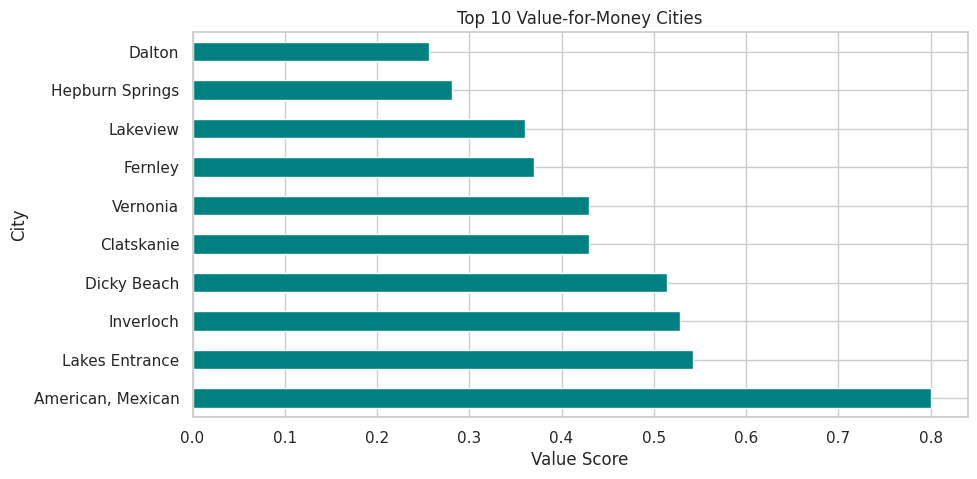

city
American, Mexican    0.800000
Lakes Entrance       0.542857
Inverloch            0.528571
Dicky Beach          0.514286
Clatskanie           0.430000
Vernonia             0.430000
Fernley              0.370000
Lakeview             0.360000
Hepburn Springs      0.281481
Dalton               0.256875
Name: value_score, dtype: float64


In [15]:
# 1. Group by city
city_stats = df.groupby('city').agg({
    'aggregate rating': 'mean',
    'average cost for two': 'mean'
})

# 2. Remove zero cost to avoid infinity
city_stats = city_stats[city_stats['average cost for two'] > 0]

# 3. Create value score
city_stats['value_score'] = city_stats['aggregate rating'] / city_stats['average cost for two']

# 4. Get top 10 cities
top_cities = city_stats['value_score'].sort_values(ascending=False).head(10)

# 5. Plot
top_cities.plot(kind='barh', color='teal')
plt.title("Top 10 Value-for-Money Cities")
plt.xlabel("Value Score")
plt.ylabel("City")
plt.show()

# 6. Print result
print(top_cities)

**Insight**: A higher value score indicates cities where restaurants offer good ratings at lower cost, meaning better value for money. These cities provide a good balance of **quality and affordability.**



---
**Objective: To study the impact of online delivery on restaurant ratings**

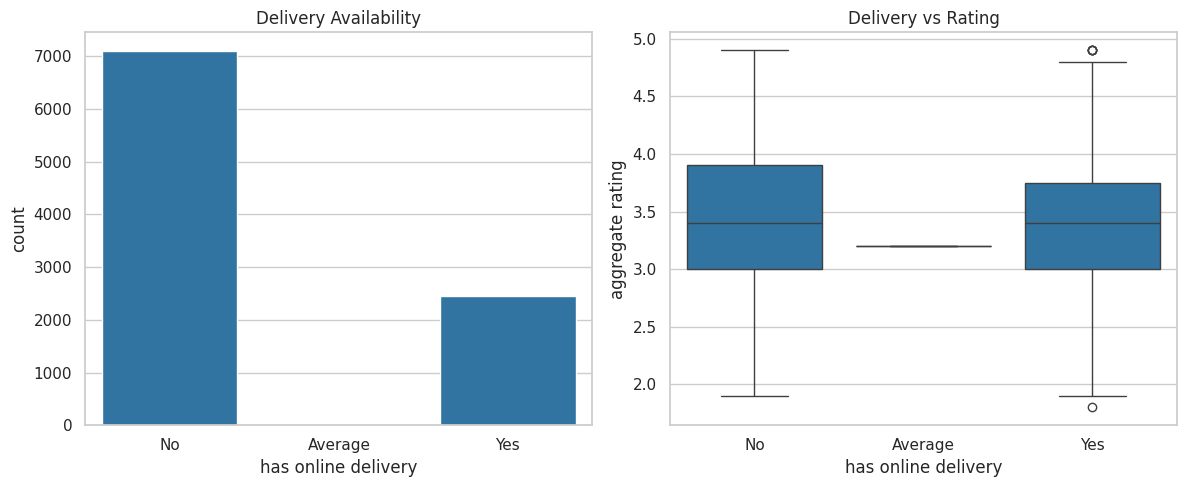

,aggregate rating
has online delivery,
Average,3.200000
No,3.467433
Yes,3.381274


In [16]:
# 1. Filter data (remove zero ratings)
rated_df = df[df['aggregate rating'] > 0]

# 2. Create plots
plt.figure(figsize=(12, 5))

# -- Plot 1: Count of restaurants
plt.subplot(1, 2, 1)
sns.countplot(x='has online delivery', data=df,palette = ['#1f77b4', '#ff7f0e'])
plt.title('Delivery Availability')

# -- Plot 2: Rating vs Delivery
plt.subplot(1, 2, 2)
sns.boxplot(x='has online delivery', y='aggregate rating',data=rated_df,palette =['#1f77b4','#ff7f0e'])
plt.title('Delivery vs Rating')

plt.tight_layout()
plt.show()

# 3. Average rating by delivery
rated_df.groupby('has online delivery')['aggregate rating'].mean()

**Insight**: Online delivery is widely adopted, but ratings are fairly similar for both groups. This suggests that while delivery adds convenience, customer satisfaction mainly depends on food quality and overall experience

-----
**Objective: To analyze the effect of table booking on restaurant ratings**

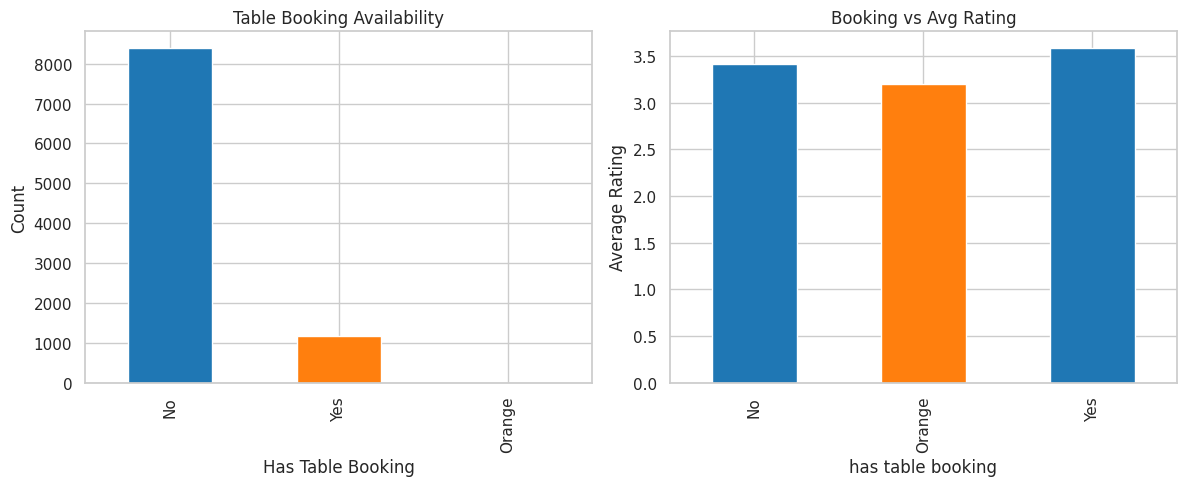

,aggregate rating
has table booking,
No,3.413970
Orange,3.200000
Yes,3.587579


In [17]:
# 1. Filter rated data
rated_df = df[df['aggregate rating'] > 0]

# 2. Create plots
plt.figure(figsize=(12, 5))

# -- Plot 1: Count of restaurants
plt.subplot(1, 2, 1)
df['has table booking'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Table Booking Availability')
plt.xlabel('Has Table Booking')
plt.ylabel('Count')

# -- Plot 2: Average rating
plt.subplot(1, 2, 2)
avg_rating = rated_df.groupby('has table booking')['aggregate rating'].mean()
avg_rating.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Booking vs Avg Rating')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

# 3.Print result
avg_rating

**Insight**: Restaurants with table booking may show slightly higher average ratings, indicating better service or customer experience. However, the difference is not very large, suggesting booking is not the only factor affecting ratings.

---
**Objective: To identify the top cuisines based on average restaurant ratings**

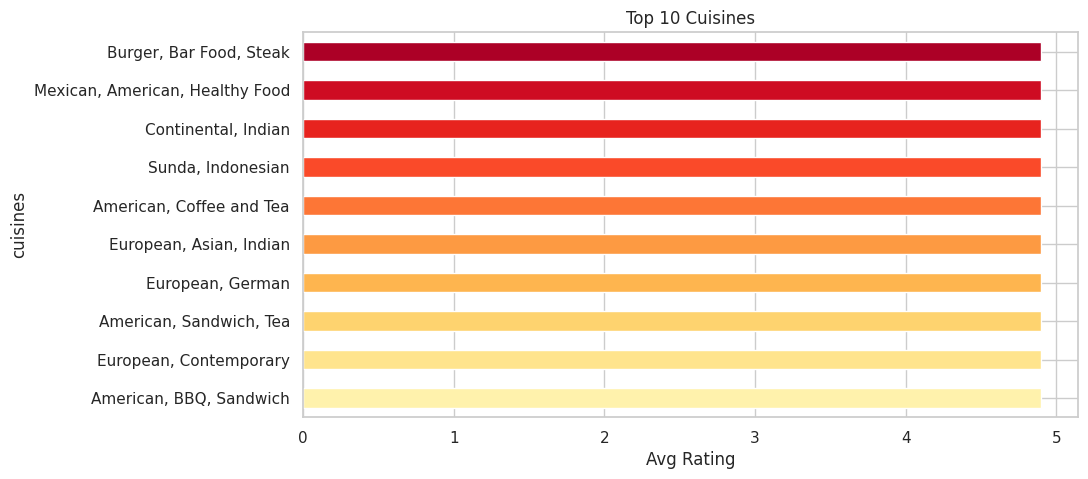

,aggregate rating
cuisines,
"American, BBQ, Sandwich",4.9
"European, Contemporary",4.9
"American, Sandwich, Tea",4.9
"European, German",4.9
"European, Asian, Indian",4.9
"American, Coffee and Tea",4.9
"Sunda, Indonesian",4.9
"Continental, Indian",4.9
"Mexican, American, Healthy Food",4.9


In [18]:
# 1. Remove zero ratings
df2 = df[df['aggregate rating'] > 0]

# 2. Top cuisines
top=(df2.groupby('cuisines')['aggregate rating'].mean().sort_values(ascending=False).head(10))

# 3. Plot
top.sort_values().plot(kind='barh',color=sns.color_palette('YlOrRd', 10))

plt.title('Top 10 Cuisines')
plt.xlabel('Avg Rating')
plt.show()

# 4. Output
top

**Insight**: Some cuisines consistently achieve higher average ratings, showing strong customer preference and satisfaction. However, since all cuisines are included, a few may rank high due to limited data. This highlights general trends but may not fully reflect reliability.



---
#SECTION 6: Executive Summary & Strategic Roadmap

| # | Business Question | Key Finding | Business Action |
|---|---|---|---|
| 1 | Top cities by restaurants | New Delhi has the most listings | Focus expansion in smaller cities |
| 2 | Excellent vs Poor rated | Most restaurants are unrated or average | Push rating campaigns for new restaurants |
| 3 | Price range vs rating | Higher price = higher rating | Highlight premium restaurants in recommendations |
| 4 | Most popular cuisines | North Indian & Chinese dominate | Prioritize these in new city onboarding |
| 5 | Best value for money cities | Tier-2 cities offer best value | Market these cities to budget travellers |
| 6 | Online delivery impact | Delivery restaurants rate higher | Encourage all restaurants to enable delivery |
| 7 | Table booking impact | Booking restaurants rate higher | Promote table booking as a quality signal |
| 8 | Highest rated cuisines | Niche cuisines score highest | Feature these cuisines for food enthusiasts |

---
# SECTION 7: Conclusion

This project performed an end-to-end Exploratory Data Analysis on the Zomato Restaurants Global Dataset,
following a structured workflow — data cleaning and 8 business-focused market insights
— to extract insights that support real-world decision-making.

Food quality, pricing, and customer experience are the primary drivers of restaurant success on Zomato.
These findings provide a data-backed foundation for smarter decisions around city expansion,
restaurant partnerships, and customer engagement.

---
*Tools Used: Python | Pandas | Matplotlib | Seaborn*

---
#SECTION 8: Data Export & Technical Handover

In [19]:
# Save file
df.to_csv('cleaned_zomato_data.csv', index=False)

print('Cleaned data download successfully!')
print()
print('Rows     : ', df.shape[0])
print('Columns  : ', df.shape[1])
print('File     : ', 'cleaned_zomato_data.csv')

# Download
files.download('cleaned_zomato_data.csv')

Cleaned data download successfully!

Rows     :  9552
Columns  :  22
File     :  cleaned_zomato_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>